# M1-T04: Preprocessing & Feature Encoding



## Task requirements and where each one is answered

| # | Requirement | Section |
|---|---|---|
| 1 | `transaction_date` and `expiration_date` parsed to datetime | 3 |
| 2 | Categorical fields encoded | 7 and 10 |
| 3 | Numerical fields scaled | 8, 9 and 10 |
| 4 | Existing temporal columns (`day_of_week`, `is_weekend`, `month`) verified against `transaction_date`, not rebuilt | 4 |
| 5 | Missing temporal features added (days since receipt) | 5 |

Rules followed in this notebook:

1. `was_spoiled` (target), `spoilage_risk` and the seven outcome columns are never used as model features.
2. The train/test split is done first. Scalers and encoders are fitted on the training rows only.
3. Columns that already exist are checked, and only rebuilt if the check fails.
4. Every column gets exactly one role (Section 6), so nothing is forgotten.
5. The discount treatments (`markdown_applied`, `discount_pct`, `selling_price`) stay in the model matrix for Track 3B and 3C, but the feature dictionary flags them `exclude (treatment)` for the Track 3A classifier. `spoilage_sensitivity` is flagged `hold until M1-T06`.
6. Four calendar features (`quarter`, `week_of_year`, `day_of_month`, `days_since_data_start`) are kept in `cleaned_dataset.csv` only, not in the model matrix.

In [1]:
from pathlib import Path
import pandas as pd

DATA_PATH = Path("perishable_goods_management.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"{DATA_PATH.name} was not found in {Path.cwd()}. "
        "Put the CSV in the same folder as this notebook and open that folder in VS Code.")

df_loaded = pd.read_csv(DATA_PATH)
print("Loaded:", DATA_PATH.name, "| shape:", df_loaded.shape)
df_loaded.head()

Loaded: perishable_goods_management.csv | shape: (100000, 42)


,record_id,product_id,product_name,category,store_id,region,supplier_id,transaction_date,expiration_date,shelf_life_days,...,selling_price,units_sold,units_wasted,waste_pct,revenue,waste_cost,profit,profit_margin_pct,supplier_score,is_promoted
0,1,BAK_DON_743,Donuts,Bakery,STORE_046,West,SUPPLIER_03,2024-09-25,2024-09-29,4,...,2.60,138,20,12.7,358.80,24.40,166.04,46.3,9,0
1,2,MEA_SAU_338,Sausages,Meat,STORE_030,Southwest,SUPPLIER_12,2023-04-14,2023-04-21,9,...,8.25,251,102,28.9,2070.75,426.36,595.21,28.7,6,0
2,3,BAK_BAG_799,Bagels,Bakery,STORE_035,Midwest,SUPPLIER_08,2024-10-25,2024-10-27,2,...,1.28,483,0,0.0,618.24,0.00,-405.72,-65.6,9,0
3,4,PHA_VAC_801,Vaccines,Pharmaceuticals,STORE_003,Midwest,SUPPLIER_11,2023-11-29,2024-02-17,87,...,209.56,477,0,0.0,99960.12,0.00,57988.89,58.0,6,0
4,5,REA_FRE_422,Fresh Pasta,Ready_to_Eat,STORE_042,West,SUPPLIER_15,2023-08-06,2023-08-09,4,...,5.28,391,0,0.0,2064.48,0.00,879.75,42.6,6,0


## 1. Imports and settings

In [2]:
import json, hashlib, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)

# settings
OUT_DIR       = Path("processed")                         # results are saved here
FIG_DIR       = OUT_DIR / "figures"
RANDOM_STATE  = 42
TEST_SIZE     = 0.20
SKEW_THRESHOLD = 1.0      # |skew| above this (and no negative values) -> log1p before scaling
OUT_DIR.mkdir(exist_ok=True); FIG_DIR.mkdir(exist_ok=True)

_v = tuple(int(x) for x in sklearn.__version__.split(".")[:2])
assert _v >= (1, 2), f"scikit-learn >= 1.2 is required (found {sklearn.__version__}); run: pip install -U scikit-learn"
print("pandas", pd.__version__, "| numpy", np.__version__, "| scikit-learn", sklearn.__version__)

pandas 2.3.3 | numpy 2.3.5 | scikit-learn 1.7.2


**What we did in Section 1:** imported the libraries and set the few settings used later (random seed 42, 20% test size, the skew limit of 1.0 and the output folders).

## 2. Schema check

The CSV was loaded in the cell above. Here we make sure it is the dataset we expect: 42 known columns, 100,000 rows, no missing values, unique `record_id`.

Some re-saved copies of this CSV lose the header of the `day_of_week` column (it shows up as `Unnamed: 17`). If that happens the cell renames it, and Section 4 then proves the values really are weekdays before we trust the name.

In [3]:
EXPECTED_COLUMNS = [
    "record_id","product_id","product_name","category","store_id","region","supplier_id",
    "transaction_date","expiration_date","shelf_life_days","days_remaining_at_purchase",
    "storage_temp","temp_deviation","base_price","cost_price","initial_quantity",
    "spoilage_sensitivity","day_of_week","is_weekend","month","daily_demand",
    "demand_variability","temp_abuse_events","distribution_hours","handling_score",
    "packaging_score","spoilage_risk","was_spoiled","quality_grade","days_until_expiry",
    "markdown_applied","discount_pct","selling_price","units_sold","units_wasted",
    "waste_pct","revenue","waste_cost","profit","profit_margin_pct","supplier_score","is_promoted",
]

df_raw = df_loaded.copy()

HEADER_REPAIRED = False
if "day_of_week" not in df_raw.columns:
    unnamed = [c for c in df_raw.columns if str(c).startswith("Unnamed")]
    assert len(unnamed) == 1, f"Cannot repair header, unnamed columns found: {unnamed}"
    df_raw = df_raw.rename(columns={unnamed[0]: "day_of_week"})
    HEADER_REPAIRED = True

print("File   :", DATA_PATH.name)
print("SHA256 :", hashlib.sha256(DATA_PATH.read_bytes()).hexdigest())
print("Shape  :", df_raw.shape)
print("day_of_week header repaired:", HEADER_REPAIRED)

M1_T02_SHA256 = "de94302b867c9debedfd45c431306623fdfc038f5ed8ca17736339b4460a6674"   # taken from m1_t02_resolution.json
same_file = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest() == M1_T02_SHA256
print("Same file as M1-T02 (SHA-256 match):", same_file)
if not same_file:
    print("  -> The bytes differ from the file used in M1-T02 (for example the CSV was re-saved). The content checks below "
          "decide whether the data is still equivalent.")

assert df_raw.shape == (100_000, 42), f"Unexpected shape {df_raw.shape}"
assert set(df_raw.columns) == set(EXPECTED_COLUMNS), set(df_raw.columns) ^ set(EXPECTED_COLUMNS)
assert df_raw.isnull().sum().sum() == 0, "Unexpected missing values"
assert df_raw["record_id"].is_unique, "record_id is not unique"
df_raw = df_raw[EXPECTED_COLUMNS]          # same column order every time
print("Schema OK: 42 expected columns, 0 missing values, unique record_id")
df_raw[["transaction_date", "expiration_date"]].head(3)

File   : perishable_goods_management.csv
SHA256 : de94302b867c9debedfd45c431306623fdfc038f5ed8ca17736339b4460a6674
Shape  : (100000, 42)
day_of_week header repaired: False
Same file as M1-T02 (SHA-256 match): True
Schema OK: 42 expected columns, 0 missing values, unique record_id


,transaction_date,expiration_date
0,2024-09-25,2024-09-29
1,2023-04-14,2023-04-21
2,2024-10-25,2024-10-27


**What we did in Section 2:** confirmed the file is the expected dataset: 100,000 rows, 42 columns, no missing values, unique `record_id`. Some re-saved copies of this CSV lose the `day_of_week` header; the cell repairs that case and prints whether it had to. The cell also prints whether the file's SHA-256 matches the one recorded in M1-T02. If it does not, the content checks in the next sections decide whether the data is still equivalent.

## 3. Parse the date columns

The dates are stored as ISO text like `2024-09-25` (year-month-day). We give the format explicitly instead of letting pandas guess, so the notebook cannot silently read a day as a month if a differently formatted copy of the file is ever used. `errors="raise"` also makes the notebook stop if a date cannot be parsed, instead of turning it into `NaT` silently.

In [4]:
DATE_COLS = ["transaction_date", "expiration_date"]
DATE_FORMAT = "%Y-%m-%d"

df = df_raw.copy()

for column in DATE_COLS:
    df[column] = pd.to_datetime(
        df[column],
        format=DATE_FORMAT,
        errors="raise"
    )

print(df[DATE_COLS].dtypes, "\n")

print(
    "transaction_date:",
    df["transaction_date"].min().date(),
    "->",
    df["transaction_date"].max().date(),
    f"({df['transaction_date'].nunique()} distinct days)"
)

print(
    "expiration_date:",
    df["expiration_date"].min().date(),
    "->",
    df["expiration_date"].max().date()
)

transaction_date    datetime64[ns]
expiration_date     datetime64[ns]
dtype: object 

transaction_date: 2023-01-01 -> 2024-12-31 (731 distinct days)
expiration_date: 2023-01-01 -> 2026-11-30


In [5]:
date_checks = pd.Series({
    "NaT in transaction_date":               int(df["transaction_date"].isna().sum()),
    "NaT in expiration_date":                int(df["expiration_date"].isna().sum()),
    "transaction_date has a time component": int((df["transaction_date"] != df["transaction_date"].dt.normalize()).sum()),
    "expiration_date has a time component":  int((df["expiration_date"]  != df["expiration_date"].dt.normalize()).sum()),
    "expiration_date before transaction_date": int((df["expiration_date"] < df["transaction_date"]).sum()),
}, name="rows")
print(date_checks.to_string())
assert (date_checks == 0).all(), "Date parsing produced invalid values"
print("\nBoth date columns parsed cleanly.")

NaT in transaction_date                    0
NaT in expiration_date                     0
transaction_date has a time component      0
expiration_date has a time component       0
expiration_date before transaction_date    0

Both date columns parsed cleanly.


**What we did in Section 3:** converted both date columns from text to real dates using the explicit format `%Y-%m-%d`. After parsing, there were no missing dates, no time-of-day parts, and no expiration date before its transaction date. Dates run from 2023-01-01 to 2024-12-31 (transactions) and up to 2026-11-30 (expirations).

## 4. Verify the existing temporal columns

`day_of_week`, `is_weekend` and `month` already exist, so we only verify them. Each one is recomputed from `transaction_date` and compared. The convention is tested first (Monday = 0 or 1, Sunday = 0 or 1, which days count as weekend), because a wrong convention shifts every weekday by one without any error.

In [6]:
t = df["transaction_date"]
pandas_dow = t.dt.dayofweek                      # Monday = 0 ... Sunday = 6

conventions = {
    "Monday = 0 ... Sunday = 6 (pandas)": pandas_dow,
    "Monday = 1 ... Sunday = 7":          pandas_dow + 1,
    "Sunday = 0 ... Saturday = 6":        (pandas_dow + 1) % 7,
}
print("day_of_week - share of rows that match each convention")
for name, expected in conventions.items():
    print(f"  {name:38s}: {(df['day_of_week'] == expected).mean():7.2%}")

weekend_defs = {
    "Saturday + Sunday":  (pandas_dow >= 5).astype(int),
    "Friday + Saturday":  pandas_dow.isin([4, 5]).astype(int),
    "Friday + Saturday + Sunday": (pandas_dow >= 4).astype(int),
}
print("\nis_weekend - share of rows that match each definition")
for name, expected in weekend_defs.items():
    print(f"  {name:38s}: {(df['is_weekend'] == expected).mean():7.2%}")

day_of_week - share of rows that match each convention
  Monday = 0 ... Sunday = 6 (pandas)    : 100.00%
  Monday = 1 ... Sunday = 7             :   0.00%
  Sunday = 0 ... Saturday = 6           :   0.00%

is_weekend - share of rows that match each definition
  Saturday + Sunday                     : 100.00%
  Friday + Saturday                     :  71.40%
  Friday + Saturday + Sunday            :  85.76%


In [7]:
verification = pd.DataFrame({
    "column":     ["day_of_week", "is_weekend", "month"],
    "rule":       ["transaction_date.dayofweek (Mon=0)", "dayofweek >= 5 (Sat, Sun)", "transaction_date.month"],
    "mismatches": [
        int((df["day_of_week"] != pandas_dow).sum()),
        int((df["is_weekend"]  != (pandas_dow >= 5).astype(int)).sum()),
        int((df["month"]       != t.dt.month).sum()),
    ],
})
verification["match_%"] = 100 * (1 - verification["mismatches"] / len(df))
verification["decision"] = np.where(verification["mismatches"] == 0, "KEEP existing column", "REBUILD from date")
print(verification.to_string(index=False))

# only rebuild a column if its check failed
for col, rule in {"day_of_week": pandas_dow, "is_weekend": (pandas_dow >= 5).astype(int), "month": t.dt.month}.items():
    if (df[col] != rule).any():
        print(f"WARNING: {col} failed verification -> rebuilt from transaction_date")
        df[col] = rule.astype(df[col].dtype)

if HEADER_REPAIRED:
    assert (df["day_of_week"] == pandas_dow).all()
    print("\nThe repaired 'Unnamed' column holds exactly the Monday=0 weekday of transaction_date, so the rename was correct.")

     column                               rule  mismatches  match_%             decision
day_of_week transaction_date.dayofweek (Mon=0)           0    100.0 KEEP existing column
 is_weekend          dayofweek >= 5 (Sat, Sun)           0    100.0 KEEP existing column
      month             transaction_date.month           0    100.0 KEEP existing column


### 4.1 Do the day-count columns agree with the dates?

This repeats a finding from the EDA notebook. It matters because it decides which column the new temporal features are built from.

In [8]:
gap = (df["expiration_date"] - df["transaction_date"]).dt.days
diff_remaining = (df["days_remaining_at_purchase"] != gap).sum()
diff_until     = (df["days_until_expiry"] != gap).sum()
lag = df["days_remaining_at_purchase"] - df["days_until_expiry"]

print(f"days_remaining_at_purchase differs from (expiration - transaction) in {diff_remaining:,} rows")
print(f"days_until_expiry          differs from (expiration - transaction) in {diff_until:,} rows")
print("\ndays_remaining_at_purchase - days_until_expiry:")
print(lag.value_counts().sort_index().rename("rows").to_frame().assign(share_pct=lambda d: (100*d['rows']/len(df)).round(1)).to_string())

assert diff_remaining == 0, "days_remaining_at_purchase should equal the date gap"
assert lag.between(0, 3).all()

days_remaining_at_purchase differs from (expiration - transaction) in 0 rows
days_until_expiry          differs from (expiration - transaction) in 74,191 rows

days_remaining_at_purchase - days_until_expiry:
    rows  share_pct
0  25809       25.8
1  26492       26.5
2  25614       25.6
3  22085       22.1


**Reading of this check.** `days_remaining_at_purchase` equals the date gap in every row, so it is consistent with the dates. `days_until_expiry` is always 0 to 3 days *lower* and never higher. It therefore does **not** describe the same moment as the two date columns. Its meaning is not documented in the dataset, so it is kept unchanged and the gap is exposed as its own feature (`expiry_lag_days`, Section 5). Nothing is rebuilt or dropped.

**What we did in Section 4:** recomputed `day_of_week`, `is_weekend` and `month` from `transaction_date`. All three had 0 mismatches out of 100,000, so all three were kept as they are (Monday = 0, weekend = Saturday and Sunday).

We also found that `days_remaining_at_purchase` equals the gap between the two dates in every row, but `days_until_expiry` does not. It is 0 to 3 days lower in 74,191 rows. Its meaning is not documented, so it was kept unchanged and the gap became its own feature in Section 5.

## 5. Add the missing temporal features

**Days since receipt.** The dataset has no receipt date, but it can be recovered from the columns we have:

```
receipt_date        = expiration_date - shelf_life_days
days_since_receipt  = transaction_date - receipt_date
```

This is the same as `shelf_life_days - days_remaining_at_purchase`. The code checks that both ways give the same answer, that the value is never negative, and that it never exceeds the shelf life.

Assumption to confirm: "receipt" is taken as the start of the shelf life. If the Task Board defines it differently, only the first two lines of the code cell change.

| Feature | Definition | Why |
|---|---|---|
| `shelf_life_used_ratio` | `days_since_receipt / shelf_life_days` | A 3-day bakery item and a 730-day pharmaceutical end up on the same 0 to 1 scale |
| `expiry_lag_days` | `days_remaining_at_purchase - days_until_expiry` | Keeps the unexplained 0 to 3 day gap from 4.1 visible |
| `quarter`, `week_of_year`, `day_of_month` | calendar parts of `transaction_date` | Seasonality at different resolutions |
| `days_since_data_start` | days since the first transaction date | Time trend across 2023 and 2024 |
| `month_sin/cos`, `dow_sin/cos` | cyclical version of the verified `month` and `day_of_week` | December is next to January and Sunday is next to Monday, which a plain 1 to 12 scale hides |

In [9]:
# days since receipt
df["receipt_date"]       = df["expiration_date"] - pd.to_timedelta(df["shelf_life_days"], unit="D")
df["days_since_receipt"] = (df["transaction_date"] - df["receipt_date"]).dt.days

# both ways of computing it must agree
assert (df["days_since_receipt"] == df["shelf_life_days"] - df["days_remaining_at_purchase"]).all()
assert df["days_since_receipt"].between(0, df["shelf_life_days"]).all()

# other temporal features
df["shelf_life_used_ratio"] = df["days_since_receipt"] / df["shelf_life_days"]
df["expiry_lag_days"]       = df["days_remaining_at_purchase"] - df["days_until_expiry"]
df["quarter"]               = df["transaction_date"].dt.quarter
df["week_of_year"]          = df["transaction_date"].dt.isocalendar().week.astype(int)
df["day_of_month"]          = df["transaction_date"].dt.day
df["days_since_data_start"] = (df["transaction_date"] - df["transaction_date"].min()).dt.days

# cyclical encoding of the verified month and day_of_week
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
df["dow_sin"]   = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"]   = np.cos(2 * np.pi * df["day_of_week"] / 7)

NEW_TEMPORAL = ["receipt_date", "days_since_receipt", "shelf_life_used_ratio", "expiry_lag_days",
                "quarter", "week_of_year", "day_of_month", "days_since_data_start",
                "month_sin", "month_cos", "dow_sin", "dow_cos"]

# range checks
assert df["shelf_life_used_ratio"].between(0, 1).all()
assert df["quarter"].between(1, 4).all() and df["week_of_year"].between(1, 53).all() and df["day_of_month"].between(1, 31).all()
assert df[NEW_TEMPORAL[1:]].notna().all().all()

df[["transaction_date", "expiration_date", "shelf_life_days", "receipt_date",
    "days_since_receipt", "shelf_life_used_ratio", "expiry_lag_days"]].head(8)

,transaction_date,expiration_date,shelf_life_days,receipt_date,days_since_receipt,shelf_life_used_ratio,expiry_lag_days
0,2024-09-25,2024-09-29,4,2024-09-25,0,0.000000,2
1,2023-04-14,2023-04-21,9,2023-04-12,2,0.222222,3
2,2024-10-25,2024-10-27,2,2024-10-25,0,0.000000,2
3,2023-11-29,2024-02-17,87,2023-11-22,7,0.080460,1
4,2023-08-06,2023-08-09,4,2023-08-05,1,0.250000,0
5,2024-08-21,2025-07-06,468,2024-03-25,149,0.318376,2
6,2023-02-18,2023-02-27,10,2023-02-17,1,0.100000,1
7,2024-04-24,2025-02-16,330,2024-03-23,32,0.096970,1


                          count     mean      std    min      25%      50%      75%      max
days_since_receipt     100000.0   11.054   27.829  0.000    0.000    1.000    4.000  243.000
shelf_life_used_ratio  100000.0    0.162    0.154  0.000    0.000    0.155    0.250    1.000
expiry_lag_days        100000.0    1.440    1.097  0.000    0.000    1.000    2.000    3.000
quarter                100000.0    2.509    1.120  1.000    2.000    3.000    4.000    4.000
week_of_year           100000.0   26.491   15.100  1.000   13.000   26.000   40.000   52.000
day_of_month           100000.0   15.750    8.800  1.000    8.000   16.000   23.000   31.000
days_since_data_start  100000.0  364.877  211.184  0.000  182.000  364.000  547.000  730.000
month_sin              100000.0   -0.003    0.705 -1.000   -0.866   -0.000    0.500    1.000
month_cos              100000.0    0.002    0.709 -1.000   -0.866    0.000    0.866    1.000
dow_sin                100000.0    0.001    0.707 -0.975   -0.782    0

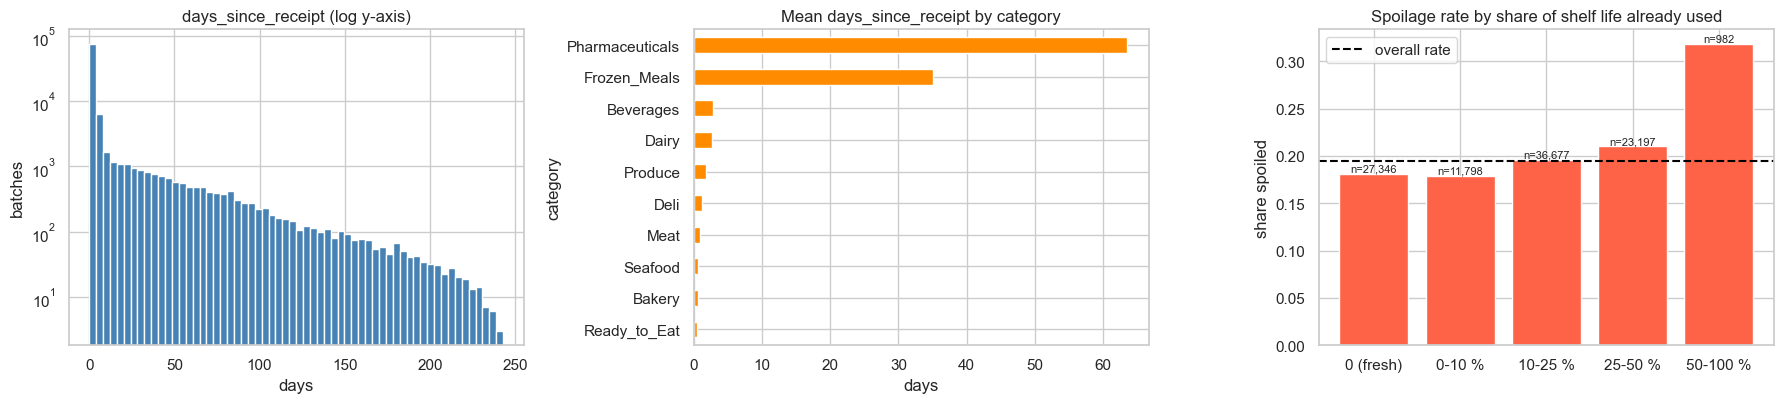

In [10]:
print(df[[c for c in NEW_TEMPORAL if c != "receipt_date"]].describe().T.round(3).to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 4.2))

axes[0].hist(df["days_since_receipt"], bins=60, color="steelblue")
axes[0].set_yscale("log")
axes[0].set(title="days_since_receipt (log y-axis)", xlabel="days", ylabel="batches")

df.groupby("category")["days_since_receipt"].mean().sort_values().plot(kind="barh", ax=axes[1], color="darkorange")
axes[1].set(title="Mean days_since_receipt by category", xlabel="days")

grp = pd.cut(df["shelf_life_used_ratio"], bins=[-0.001, 0, 0.1, 0.25, 0.5, 1.0],
             labels=["0 (fresh)", "0-10 %", "10-25 %", "25-50 %", "50-100 %"])
rate = df.groupby(grp, observed=True)["was_spoiled"].agg(["mean", "size"])
axes[2].bar(rate.index.astype(str), rate["mean"], color="tomato")
axes[2].axhline(df["was_spoiled"].mean(), color="black", ls="--", label="overall rate")
for i, (m, n) in enumerate(zip(rate["mean"], rate["size"])):
    axes[2].text(i, m, f"n={n:,}", ha="center", va="bottom", fontsize=8)
axes[2].set(title="Spoilage rate by share of shelf life already used", ylabel="share spoiled"); axes[2].legend()

plt.tight_layout(); plt.savefig(FIG_DIR / "t04_01_temporal_features.png", dpi=150, bbox_inches="tight"); plt.show()

**What we did in Section 5:** built `days_since_receipt` (0 to 243 days, never negative, never above the shelf life) and the other temporal features from the table above. The charts show that pharmaceuticals and frozen meals are the oldest at sale, and that the spoilage rate rises once more than half of the shelf life has been used (about 32%, against 19.4% overall, though only about 1,000 batches are in that group). The last four calendar features (`quarter`, `week_of_year`, `day_of_month`, `days_since_data_start`) are kept in the cleaned dataset only (Section 6).

## 6. Column role registry

Every column gets exactly one role. The assertion at the end fails if a column is missing or listed twice.

| Role | Meaning | Treatment |
|---|---|---|
| identifier | row or product key | not a feature |
| datetime | parsed dates | not fed to models, replaced by the temporal features |
| nominal | categories with no order | one-hot |
| ordinal | categories with an order | integer code |
| binary | already 0/1 | unchanged |
| cyclical | sin/cos pairs | unchanged |
| numeric | continuous or count features | scaled (log1p first if heavily skewed) |
| calendar_raw | verified `month`, `day_of_week` | kept in the cleaned dataset, replaced by sin/cos in the model matrix |
| target | `was_spoiled` | never a feature |
| reserved | `spoilage_risk` | never a Track 3A feature (M1-T01), kept as benchmark and Track 3B control |
| outcome | results that happen after the sale | never features |
| calendar_extra | `quarter`, `week_of_year`, `day_of_month`, `days_since_data_start` | kept in the cleaned dataset only. EDA found no trend or seasonality, and `days_since_data_start` cannot extrapolate if Track 3A is later tested on a later year |

**Flags** (not roles, they sit on top of the roles in the feature dictionary): `markdown_applied`, `discount_pct` and `selling_price` are discount treatments, flagged `exclude (treatment)` for Track 3A. `spoilage_sensitivity` is flagged `hold until M1-T06` because the M1-T01 log requires a leakage check before it is used.

In [11]:
# higher number = better quality
QUALITY_ORDER = {"C": 1, "B": 2, "A": 3}
df["quality_grade_ord"] = df["quality_grade"].map(QUALITY_ORDER)
assert df["quality_grade_ord"].notna().all(), "Unmapped quality_grade value"

ROLES = {
    "identifier":   ["record_id", "product_id"],
    "datetime":     ["transaction_date", "expiration_date", "receipt_date"],
    "nominal":      ["category", "region", "product_name", "store_id", "supplier_id"],
    "ordinal_raw":  ["quality_grade"],                       # text label, replaced by quality_grade_ord
    "ordinal":      ["quality_grade_ord"],
    "binary":       ["is_weekend", "is_promoted", "markdown_applied"],
    "cyclical":     ["month_sin", "month_cos", "dow_sin", "dow_cos"],
    "calendar_raw": ["day_of_week", "month"],
    "calendar_extra": ["quarter", "week_of_year", "day_of_month", "days_since_data_start"],   # cleaned dataset only
    "numeric": [
        # shelf life and timing
        "shelf_life_days", "days_remaining_at_purchase", "days_until_expiry", "days_since_receipt",
        "shelf_life_used_ratio", "expiry_lag_days",
        # storage and handling
        "storage_temp", "temp_deviation", "temp_abuse_events", "distribution_hours",
        "handling_score", "packaging_score", "supplier_score", "spoilage_sensitivity",
        # price and demand
        "base_price", "cost_price", "selling_price", "discount_pct",
        "initial_quantity", "daily_demand", "demand_variability",
    ],
    "target":   ["was_spoiled"],
    "reserved": ["spoilage_risk"],
    "outcome":  ["units_sold", "units_wasted", "waste_pct", "revenue", "waste_cost", "profit", "profit_margin_pct"],
}

# every column must have exactly one role
assigned = [c for cols in ROLES.values() for c in cols]
dups     = sorted({c for c in assigned if assigned.count(c) > 1})
missing  = sorted(set(df.columns) - set(assigned))
unknown  = sorted(set(assigned) - set(df.columns))
assert not dups,    f"Columns listed in more than one role: {dups}"
assert not missing, f"Columns without a role: {missing}"
assert not unknown, f"Registry names that are not columns: {unknown}"

for b in ROLES["binary"]:
    assert set(df[b].unique()) <= {0, 1}, f"{b} is not binary"

print(f"All {df.shape[1]} columns have exactly one role:\n")
print(pd.Series({k: len(v) for k, v in ROLES.items()}, name="columns").to_string())

# flags used later in the feature dictionary (Section 11)
TREATMENT_COLS = ["markdown_applied", "discount_pct", "selling_price"]   # discount treatments
HOLD_COLS      = ["spoilage_sensitivity"]                               # wait for the M1-T06 leakage check
assert set(TREATMENT_COLS + HOLD_COLS) <= set(df.columns)

All 55 columns have exactly one role:

identifier         2
datetime           3
nominal            5
ordinal_raw        1
ordinal            1
binary             3
cyclical           4
calendar_raw       2
calendar_extra     4
numeric           21
target             1
reserved           1
outcome            7


**What we did in Section 6:** gave each of the 55 columns (42 original plus the new ones) exactly one role and checked that none is missing or duplicated. This is also where `quality_grade` was turned into the ordinal `quality_grade_ord`, and where the forbidden columns (target, `spoilage_risk`, outcomes) were listed. Four calendar features got the role `calendar_extra` (cleaned dataset only), and the discount treatments and `spoilage_sensitivity` were listed so they can be flagged in the feature dictionary (Section 11).

## 7. Categorical fields

| Column | Levels | Encoding | Why |
|---|---|---|---|
| `category` | 10 | one-hot | No order between Dairy and Meat. Numbering them 0 to 9 would tell a linear model that Seafood is "nine times" Bakery. |
| `region` | 5 | one-hot | Same reason |
| `product_name` | 63 | one-hot | Real product types with enough rows each |
| `store_id` | 50 | one-hot | EDA found stores close to the average, so a model may ignore them, but the information is kept |
| `supplier_id` | 20 | one-hot | Same |
| `quality_grade` | 3 | ordinal C=1, B=2, A=3 | The grades have a natural order, so one column is enough |
| `product_id` | 45,301 | not used as a feature | Almost one value per row, a model would memorise it. Its useful parts already exist as `category` and `product_name`. |

Target encoding (replacing each level by its spoilage rate) was not used. It would build a feature from `was_spoiled` to predict `was_spoiled`, which is the leakage this project avoids.

In [12]:
card = pd.DataFrame({
    "unique_levels": df[ROLES["nominal"] + ["quality_grade", "product_id"]].nunique(),
    "min_rows_per_level": [df[c].value_counts().min() for c in ROLES["nominal"] + ["quality_grade", "product_id"]],
    "max_rows_per_level": [df[c].value_counts().max() for c in ROLES["nominal"] + ["quality_grade", "product_id"]],
})
print(card.to_string())

# each product_name should belong to one category only
assert df.groupby("product_name")["category"].nunique().max() == 1
assert df.groupby("store_id")["region"].nunique().max() == 1
print("\nEach product_name belongs to one category, each store to one region (hierarchies are clean).")

print("\nquality_grade vs handling_score (rows). The grade follows handling_score in overlapping bands,")
print("which is consistent with a grade built from pre-sale scores (handling, packaging). Confirm in the data dictionary.")
print(pd.crosstab(df["handling_score"], df["quality_grade"]).to_string())

               unique_levels  min_rows_per_level  max_rows_per_level
category                  10                9901               10120
region                     5               14034               29926
product_name              63                1339                2040
store_id                  50                1877                2087
supplier_id               20                4905                5146
quality_grade              3               14298               50037
product_id             45301                   1                  16

Each product_name belongs to one category, each store to one region (hierarchies are clean).

quality_grade vs handling_score (rows). The grade follows handling_score in overlapping bands,
which is consistent with a grade built from pre-sale scores (handling, packaging). Confirm in the data dictionary.
quality_grade       A     B     C
handling_score                   
4                   0  7211  7061
5                   0  9572  4786
6      

In [13]:
# is quality_grade a bucket of the pre-sale scores?
score_sum = df["handling_score"] + df["packaging_score"]
grade_by_sum = pd.crosstab(score_sum, df["quality_grade"])
print(grade_by_sum.to_string())

purity = grade_by_sum.max(axis=1).sum() / grade_by_sum.to_numpy().sum()
print(f"\nShare of rows whose grade is the most common grade for their handling+packaging sum: {purity:.2%}")
if purity > 0.99:
    print("-> quality_grade is (almost) a deterministic bucket of handling_score + packaging_score: it is derived from "
          "pre-sale scores, so it is not a leakage risk, but it is partly redundant with them.")
else:
    print("-> quality_grade is NOT fully determined by handling_score + packaging_score. "
          "Confirm its definition in the data dictionary before relying on it.")

quality_grade      A      B     C
row_0                            
9                  0      0  2340
10                 0      0  4640
11                 0      0  7318
12                 0   9579     0
13                 0  11825     0
14                 0  14437     0
15                 0  14196     0
16             11952      0     0
17              9458      0     0
18              7049      0     0
19              4806      0     0
20              2400      0     0

Share of rows whose grade is the most common grade for their handling+packaging sum: 100.00%
-> quality_grade is (almost) a deterministic bucket of handling_score + packaging_score: it is derived from pre-sale scores, so it is not a leakage risk, but it is partly redundant with them.


**What we did in Section 7:** checked how many values each categorical column has, and confirmed that each product belongs to one category and each store to one region. We also looked at `quality_grade` against `handling_score`: the grade follows the handling score in overlapping bands, which fits a grade built from pre-sale scores. That should be confirmed in the data dictionary. The next cell then tests whether `quality_grade` is a bucket of `handling_score + packaging_score`; its printed result says whether the grade is derived from pre-sale scores.

## 8. Train / test split

The split is done before anything is fitted. It is stratified on `was_spoiled`, so both parts keep the same spoilage rate, and the seed is fixed so it can be reproduced. The label is saved as a `split` column so later tasks use the same rows.

Why before scaling: a scaler fitted on all rows would carry the test rows' mean and standard deviation into the training features.

This is a random split. If Track 3A is later evaluated as a forecast (train on 2023, test on 2024), only this cell changes.

In [14]:
idx_train, idx_test = train_test_split(
    df.index, test_size=TEST_SIZE, stratify=df["was_spoiled"], random_state=RANDOM_STATE)
df["split"] = "train"
df.loc[idx_test, "split"] = "test"

summary = df.groupby("split")["was_spoiled"].agg(rows="size", spoiled_rate="mean").round(4)
print(summary.to_string())
assert abs(summary.loc["train", "spoiled_rate"] - summary.loc["test", "spoiled_rate"]) < 0.002
assert set(idx_train).isdisjoint(idx_test) and len(idx_train) + len(idx_test) == len(df)

        rows  spoiled_rate
split                     
test   20000        0.1944
train  80000        0.1944


**What we did in Section 8:** split the rows 80,000 train / 20,000 test, stratified on `was_spoiled`. Both parts have a spoilage rate of 19.44%.

## 9. Numeric columns: skewness and scaling choice

Scaling keeps columns with large units (`base_price` up to about 500, `daily_demand` up to about 1,100) from dominating columns with small ones (`handling_score` 4 to 10) in linear, KNN and neural models. Tree models do not need it.

* Normal-looking columns: `StandardScaler` (subtract the mean, divide by the standard deviation).
* Heavily right-skewed columns that are never negative: `log1p` first, then `StandardScaler`.
* Min-max scaling was not used. One extreme value, like a 730-day shelf life, would squeeze all other values into a tiny part of the 0 to 1 range.
* Binary columns and the sin/cos pairs are left unchanged.

Skewness is measured on the training rows only.

In [15]:
train = df[df["split"] == "train"]
num_cols = ROLES["numeric"] + ROLES["ordinal"]

skew_tbl = pd.DataFrame({
    "skew_train": train[num_cols].skew(),
    "min": train[num_cols].min(),
    "max": train[num_cols].max(),
})
skew_tbl["treatment"] = np.where((skew_tbl["skew_train"].abs() > SKEW_THRESHOLD) & (skew_tbl["min"] >= 0),
                                 "log1p + scale", "scale")
LOG_COLS   = skew_tbl.index[skew_tbl["treatment"] == "log1p + scale"].tolist()
SCALE_COLS = skew_tbl.index[skew_tbl["treatment"] == "scale"].tolist()

print(skew_tbl.sort_values("skew_train", ascending=False).round(2).to_string())
print(f"\nlog1p + scale ({len(LOG_COLS)}): {LOG_COLS}")
print(f"scale only    ({len(SCALE_COLS)}): {SCALE_COLS}")

# skewed columns with negative values cannot use log1p
neg_skewed = skew_tbl[(skew_tbl["skew_train"].abs() > SKEW_THRESHOLD) & (skew_tbl["min"] < 0)].index.tolist()
print("Skewed columns with negative values (log1p not applicable):", neg_skewed or "none")

                            skew_train    min      max      treatment
days_since_receipt                3.83   0.00   240.00  log1p + scale
cost_price                        3.82   0.41   346.06  log1p + scale
selling_price                     3.68   0.26   499.98  log1p + scale
base_price                        3.65   1.00   499.98  log1p + scale
daily_demand                      3.40   0.00  1118.00  log1p + scale
days_until_expiry                 2.80   0.00   720.00  log1p + scale
days_remaining_at_purchase        2.80   0.00   723.00  log1p + scale
shelf_life_days                   2.72   1.00   730.00  log1p + scale
discount_pct                      1.81   0.00     0.75  log1p + scale
shelf_life_used_ratio             1.69   0.00     1.00  log1p + scale
temp_abuse_events                 1.67   0.00     9.00  log1p + scale
temp_deviation                    0.99   0.00     9.00          scale
expiry_lag_days                   0.07   0.00     3.00          scale
handling_score      

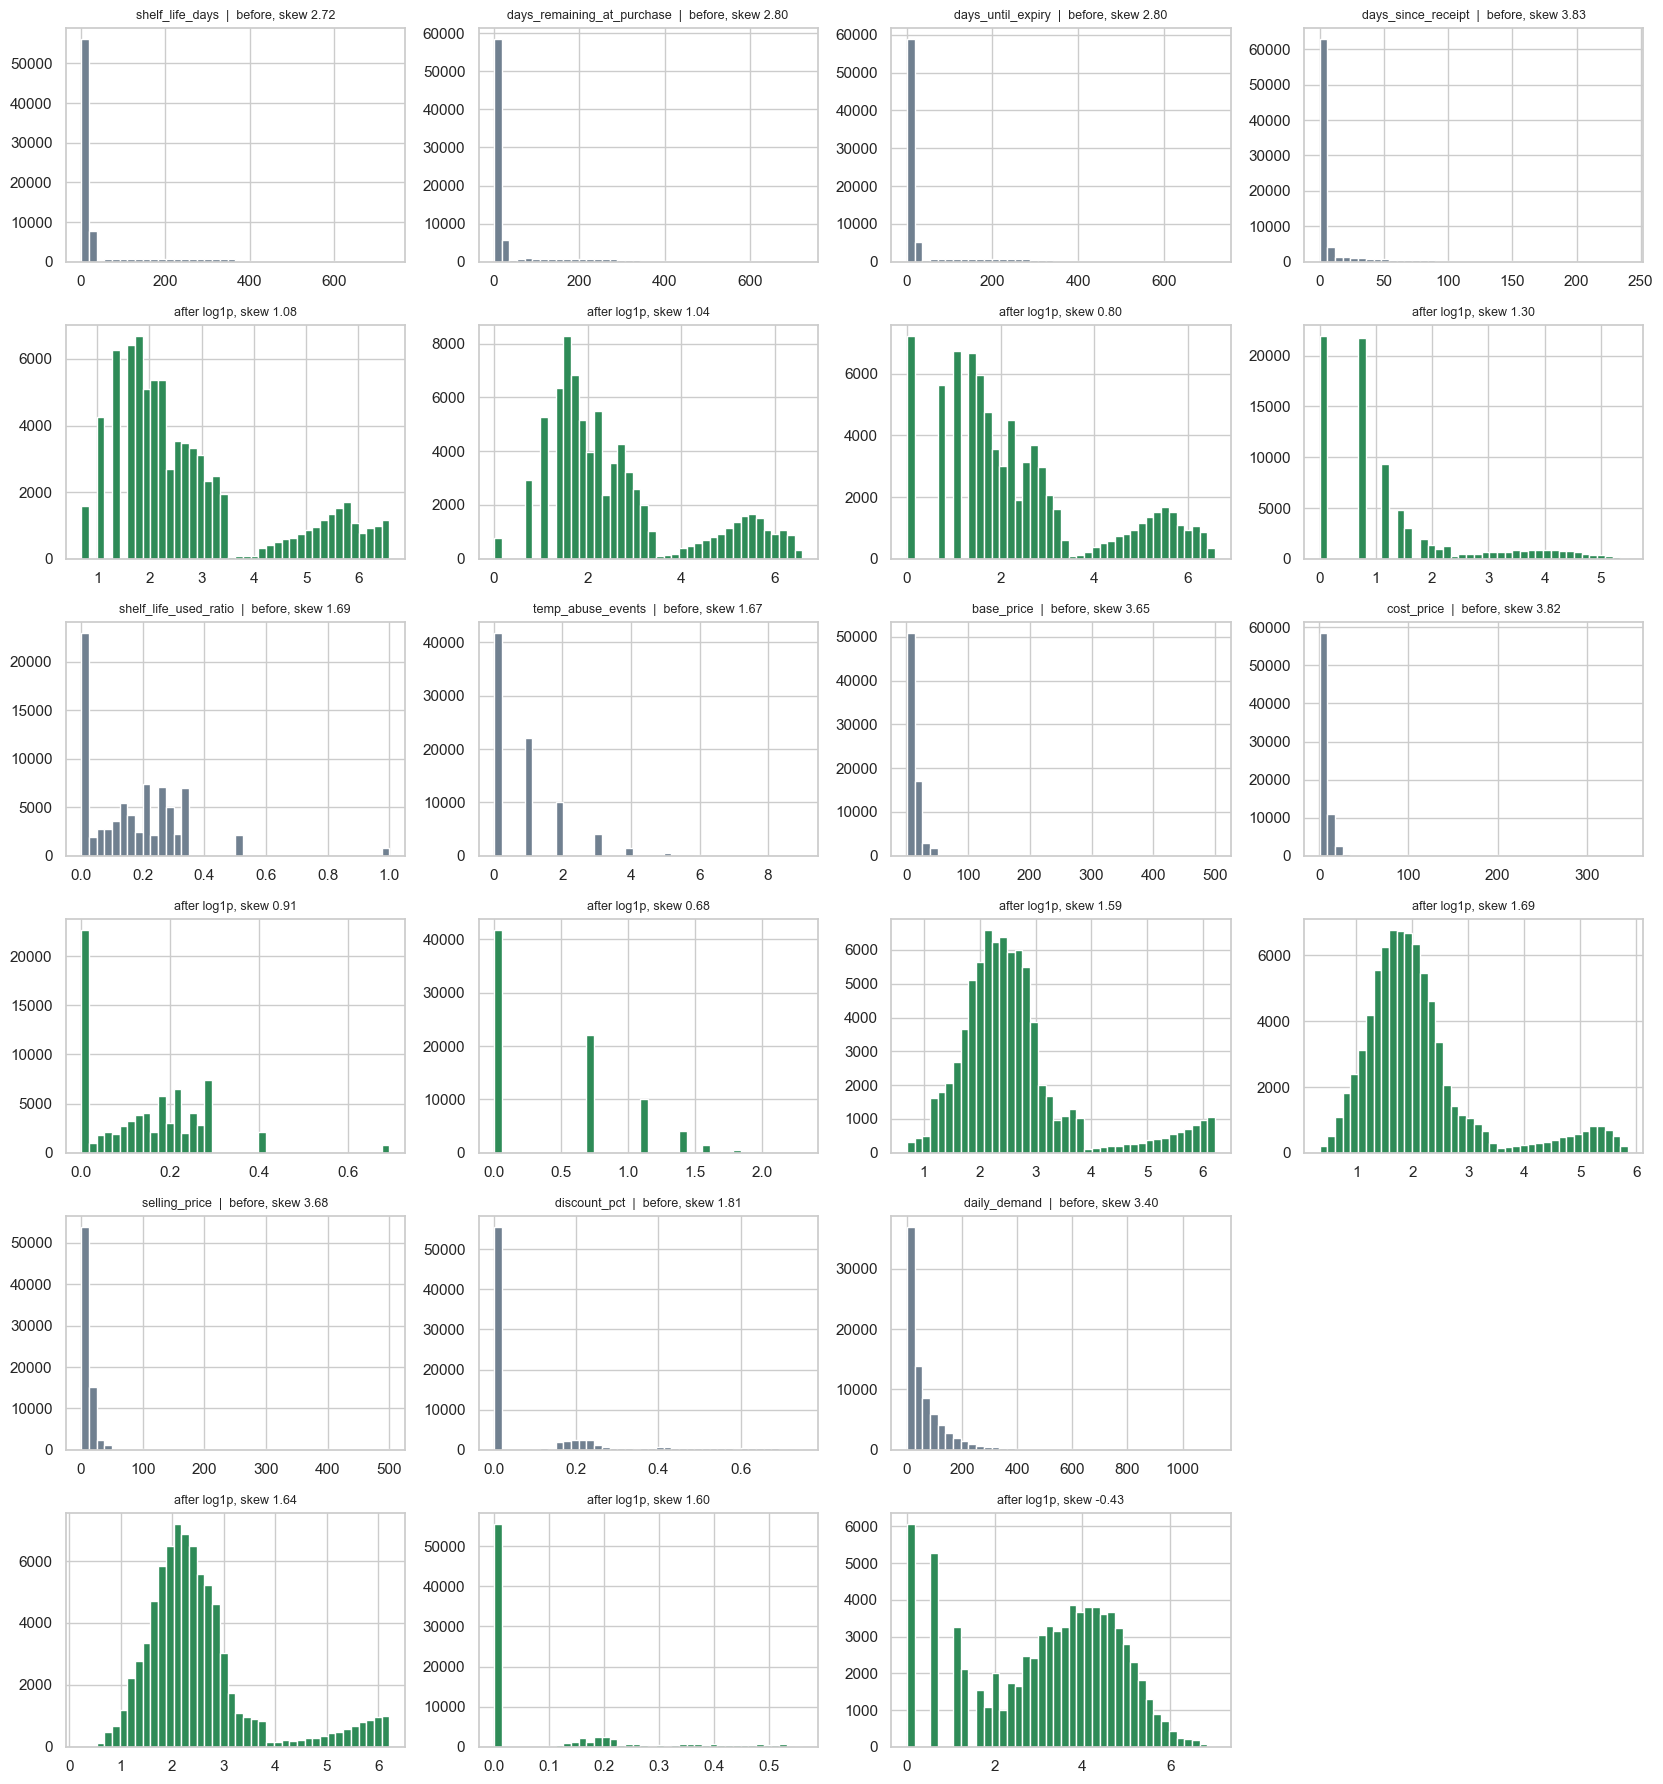

Note: log1p reduces the skew but cannot remove it for zero-heavy columns (discount_pct, temp_abuse_events, days_since_receipt), where most rows are exactly 0. Their remaining shape is a real feature of the data, not a scaling error.


In [16]:
ncol = 4
nblk = int(np.ceil(len(LOG_COLS) / ncol))
fig, axes = plt.subplots(2 * nblk, ncol, figsize=(4.2 * ncol, 3.0 * 2 * nblk))
axes = np.atleast_2d(axes)
for ax in axes.ravel():
    ax.axis("off")
for j, c in enumerate(LOG_COLS):
    r, k = divmod(j, ncol)
    a0, a1 = axes[2 * r, k], axes[2 * r + 1, k]
    a0.axis("on"); a1.axis("on")
    a0.hist(train[c], bins=40, color="slategrey")
    a0.set_title(f"{c}  |  before, skew {train[c].skew():.2f}", fontsize=9)
    z = np.log1p(train[c])
    a1.hist(z, bins=40, color="seagreen")
    a1.set_title(f"after log1p, skew {z.skew():.2f}", fontsize=9)
plt.tight_layout(); plt.savefig(FIG_DIR / "t04_02_skew_before_after.png", dpi=150, bbox_inches="tight"); plt.show()
print("Note: log1p reduces the skew but cannot remove it for zero-heavy columns (discount_pct, temp_abuse_events, "
      "days_since_receipt), where most rows are exactly 0. Their remaining shape is a real feature of the data, not a scaling error.")

**What we did in Section 9:** measured skewness on the training rows. 11 columns are heavily skewed and never negative (prices, shelf-life columns, `daily_demand`, `days_since_receipt`, `discount_pct` and a few more), so they get `log1p` then standard scaling. The remaining numeric columns get standard scaling only (both lists are printed above). The charts show the skew before and after. For columns where most rows are exactly 0 (`discount_pct`, `temp_abuse_events`), some skew remains, because that is how the data really looks.

## 10. Build and fit the preprocessing pipeline

One `ColumnTransformer` holds all the rules from Sections 7 and 9. It is fitted on the training rows only, then applied to all 100,000 rows. `handle_unknown="ignore"` means a store or product never seen in training becomes an all-zero row instead of an error.

In [17]:
log_branch = Pipeline([
    ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("scale", StandardScaler()),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num_log_scaled", log_branch,                 LOG_COLS),
        ("num_scaled",     StandardScaler(),           SCALE_COLS),
        ("cat_onehot",     OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.float32),
                                                       ROLES["nominal"]),
        ("binary_cyclical_passthrough", "passthrough", ROLES["binary"] + ROLES["cyclical"]),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
).set_output(transform="pandas")

FEATURE_INPUT_COLS = LOG_COLS + SCALE_COLS + ROLES["nominal"] + ROLES["binary"] + ROLES["cyclical"]

# no target / outcome / identifier / date column may be a feature
FORBIDDEN = set(ROLES["target"] + ROLES["reserved"] + ROLES["outcome"] + ROLES["identifier"] + ROLES["datetime"])
leaks = FORBIDDEN & set(FEATURE_INPUT_COLS)
assert not leaks, f"Forbidden columns in feature matrix: {leaks}"
assert len(FEATURE_INPUT_COLS) == len(set(FEATURE_INPUT_COLS))

X_train = df.loc[df["split"] == "train", FEATURE_INPUT_COLS]
preprocessor.fit(X_train)                                  # fitted on training rows only
X_all = preprocessor.transform(df[FEATURE_INPUT_COLS])     # applied to every row

print("Feature matrix:", X_all.shape, "| dtype mix:", X_all.dtypes.astype(str).value_counts().to_dict())
print("Raw input columns used :", len(FEATURE_INPUT_COLS))
print("Encoded feature columns:", X_all.shape[1])

Feature matrix: (100000, 177) | dtype mix: {'float32': 148, 'float64': 26, 'int64': 3}
Raw input columns used : 34
Encoded feature columns: 177


### 10.1 Sanity checks

In [18]:
tr = X_all[df["split"] == "train"]
te = X_all[df["split"] == "test"]
scaled_cols = LOG_COLS + SCALE_COLS
onehot_cols = [c for c in X_all.columns if c not in scaled_cols + ROLES["binary"] + ROLES["cyclical"]]

# no NaN or inf
assert np.isfinite(X_all.to_numpy(dtype=float)).all(), "NaN or inf in the feature matrix"

# scaled columns: train mean about 0, std about 1
assert tr[scaled_cols].mean().abs().max() < 1e-4
assert (tr[scaled_cols].std(ddof=0) - 1).abs().max() < 1e-3

# each one-hot group has exactly one 1 per row
for col in ROLES["nominal"]:
    block = [c for c in onehot_cols if c.startswith(col + "_")]
    assert (X_all[block].sum(axis=1) == 1).all(), f"one-hot group {col} is not exactly-one-hot"

# pass-through columns are unchanged
for c in ROLES["binary"] + ROLES["cyclical"]:
    assert np.allclose(X_all[c].to_numpy(dtype=float), df[c].to_numpy(dtype=float))

print("All checks passed.\n")
print("Train columns are centred exactly. Test columns only approximately, because the scaler never saw them.")
print(pd.DataFrame({"train_mean": tr[scaled_cols].mean(), "test_mean": te[scaled_cols].mean(),
                    "train_std": tr[scaled_cols].std(ddof=0), "test_std": te[scaled_cols].std(ddof=0)}).round(3).head(10).to_string())

All checks passed.

Train columns are centred exactly. Test columns only approximately, because the scaler never saw them.
                            train_mean  test_mean  train_std  test_std
shelf_life_days                    0.0     -0.000        1.0     1.005
days_remaining_at_purchase         0.0     -0.002        1.0     1.005
days_until_expiry                 -0.0     -0.003        1.0     1.005
days_since_receipt                -0.0      0.009        1.0     1.005
shelf_life_used_ratio             -0.0      0.015        1.0     1.010
temp_abuse_events                  0.0     -0.000        1.0     0.997
base_price                         0.0      0.001        1.0     1.004
cost_price                        -0.0      0.001        1.0     1.004
selling_price                      0.0     -0.000        1.0     1.006
discount_pct                      -0.0      0.007        1.0     1.006


### 10.2 Following one row through the pipeline

The table takes one training row and shows the raw value, the value after `log1p` (where used), the pipeline output, and the same number recomputed by hand from the stored mean and standard deviation. The two last columns must match.

In [19]:
row_id   = df[df["split"] == "train"].sample(1, random_state=RANDOM_STATE).index[0]
raw_row  = df.loc[row_id]
log_scaler  = preprocessor.named_transformers_["num_log_scaled"].named_steps["scale"]
plain_scaler = preprocessor.named_transformers_["num_scaled"]

trace = []
for c in LOG_COLS[:6]:
    k = LOG_COLS.index(c)
    after_log = np.log1p(raw_row[c])
    by_hand = (after_log - log_scaler.mean_[k]) / log_scaler.scale_[k]
    trace.append([c, "log1p + scale", raw_row[c], after_log, X_all.loc[row_id, c], by_hand])
for c in SCALE_COLS[:6]:
    k = SCALE_COLS.index(c)
    by_hand = (raw_row[c] - plain_scaler.mean_[k]) / plain_scaler.scale_[k]
    trace.append([c, "scale", raw_row[c], np.nan, X_all.loc[row_id, c], by_hand])

trace = pd.DataFrame(trace, columns=["feature", "treatment", "raw_value", "after_log1p", "pipeline_output", "recomputed_by_hand"])
assert np.allclose(trace["pipeline_output"], trace["recomputed_by_hand"], atol=1e-4)
print(f"record_id {raw_row['record_id']}  |  category={raw_row['category']}, region={raw_row['region']}, "
      f"quality_grade={raw_row['quality_grade']} (-> {raw_row['quality_grade_ord']})")
display(trace.round(4).style.bar(subset=["pipeline_output"], align="mid", color=["#d65f5f", "#5fba7d"]))

hot = X_all.loc[row_id, [c for c in onehot_cols if X_all.loc[row_id, c] == 1]]
print("\nOne-hot columns that are 1 for this row:", list(hot.index))

record_id 58932  |  category=Pharmaceuticals, region=Northeast, quality_grade=B (-> 2)


,feature,treatment,raw_value,after_log1p,pipeline_output,recomputed_by_hand
0,shelf_life_days,log1p + scale,257.000000,5.553000,1.828300,1.828300
1,days_remaining_at_purchase,log1p + scale,216.000000,5.379900,1.825800,1.825800
2,days_until_expiry,log1p + scale,215.000000,5.375300,1.766000,1.766000
3,days_since_receipt,log1p + scale,41.000000,3.737700,1.882500,1.882500
4,shelf_life_used_ratio,log1p + scale,0.159500,0.148000,0.049200,0.049200
5,temp_abuse_events,log1p + scale,0.000000,0.000000,-0.868800,-0.868800
6,expiry_lag_days,scale,1.000000,nan,-0.398400,-0.398400
7,storage_temp,scale,3.100000,nan,-0.002900,-0.002900
8,temp_deviation,scale,1.900000,nan,0.249700,0.249700
9,distribution_hours,scale,50.400000,nan,0.632400,0.632400



One-hot columns that are 1 for this row: ['category_Pharmaceuticals', 'region_Northeast', 'product_name_Antibiotics', 'store_id_STORE_039', 'supplier_id_SUPPLIER_08']


**What we did in Section 10:** built one `ColumnTransformer` with four parts: log + scale, scale, one-hot, and pass-through for binary and sin/cos columns. It was fitted on the training rows and applied to everything. The result is 177 feature columns: 148 one-hot columns, 22 scaled columns, and 7 pass-through columns (3 binary, 4 sin/cos). The checks confirm there are no NaN values, scaled columns have mean 0 and standard deviation 1 on train, each one-hot group has exactly one 1 per row, and the hand-computed values in 10.2 match the pipeline.

## 11. Save the results

| File | Contents | Used by |
|---|---|---|
| `cleaned_dataset.csv` | all original columns, dates as `YYYY-MM-DD`, the new temporal features, `quality_grade_ord`, `split`. Not scaled, labels kept readable | Task 5 and any analysis that needs real units |
| `model_ready_dataset.csv` | `record_id`, `split`, the encoded and scaled features, then target / reserved / outcome columns unscaled | Track 3A, 3B, 3C |
| `preprocessor.joblib` | the fitted `ColumnTransformer` | applying the same transformation to new data |
| `feature_dictionary.csv` | one line per column of `model_ready_dataset.csv`: role, source column, transformation, Track 3A use | documentation |
| `m1_t04_preprocessing_report.json` | counts, decisions, parameters | EDA report |

In [20]:
# cleaned dataset (not scaled)
cleaned = df.copy()
for c in ROLES["datetime"]:
    cleaned[c] = cleaned[c].dt.strftime("%Y-%m-%d")
cleaned.to_csv(OUT_DIR / "cleaned_dataset.csv", index=False)

# model-ready dataset
keep_after = ROLES["target"] + ROLES["reserved"] + ROLES["outcome"]
model_ready = pd.concat(
    [df[["record_id", "split"]].reset_index(drop=True),
     X_all.reset_index(drop=True),
     df[keep_after].reset_index(drop=True)], axis=1)
assert model_ready.shape[0] == len(df) and model_ready["record_id"].is_unique
model_ready.to_csv(OUT_DIR / "model_ready_dataset.csv", index=False, float_format="%.6g")

# fitted preprocessor
joblib.dump(preprocessor, OUT_DIR / "preprocessor.joblib")

# feature dictionary
fd = []
for c in model_ready.columns:
    if c in ("record_id",):      fd.append([c, "identifier", c, "key, unchanged"])
    elif c == "split":           fd.append([c, "split_label", "was_spoiled (stratifier)", "stratified 80/20, seed %d" % RANDOM_STATE])
    elif c in LOG_COLS:          fd.append([c, "feature", c, "log1p then StandardScaler (fit on train)"])
    elif c in SCALE_COLS:        fd.append([c, "feature", c, "StandardScaler (fit on train)"])
    elif c in ROLES["binary"]:   fd.append([c, "feature", c, "binary 0/1, unchanged"])
    elif c in ROLES["cyclical"]: fd.append([c, "feature", c, "sin/cos of verified month / day_of_week, unchanged"])
    elif c in keep_after:
        role = "target" if c in ROLES["target"] else ("reserved" if c in ROLES["reserved"] else "outcome")
        fd.append([c, role, c, "unscaled, never a Track 3A feature"])
    else:
        src = next(n for n in ROLES["nominal"] if c.startswith(n + "_"))
        fd.append([c, "feature", src, "one-hot"])
feature_dictionary = pd.DataFrame(fd, columns=["column", "role", "source_column", "transformation"])

def track_3a_use(col, role):
    if role in ("target", "reserved", "outcome"): return "never"
    if role in ("identifier", "split_label"):      return "n/a"
    if col in TREATMENT_COLS:                      return "exclude (treatment)"
    if col in HOLD_COLS:                           return "hold until M1-T06"
    return "allowed"

feature_dictionary["track_3a_use"] = [track_3a_use(c, r) for c, r in zip(feature_dictionary["column"], feature_dictionary["role"])]
feature_dictionary.to_csv(OUT_DIR / "feature_dictionary.csv", index=False)
assert set(feature_dictionary["column"]) == set(model_ready.columns)

# report
report = {
    "task": "M1-T04",
    "dataset_sha256": hashlib.sha256(DATA_PATH.read_bytes()).hexdigest(),
    "rows": int(len(df)),
    "columns_raw": 42,
    "day_of_week_header_repaired": HEADER_REPAIRED,
    "date_format": DATE_FORMAT,
    "temporal_verification": {r.column: {"mismatches": int(r.mismatches), "decision": r.decision}
                              for r in verification.itertuples()},
    "days_remaining_at_purchase_matches_date_gap": bool(diff_remaining == 0),
    "days_until_expiry_rows_differing_from_date_gap": int(diff_until),
    "new_temporal_features": NEW_TEMPORAL,
    "quality_grade_order": QUALITY_ORDER,
    "split": {"test_size": TEST_SIZE, "random_state": RANDOM_STATE, "stratified_on": "was_spoiled",
              "train_rows": int((df["split"] == "train").sum()), "test_rows": int((df["split"] == "test").sum())},
    "skew_threshold": SKEW_THRESHOLD,
    "log1p_scaled_columns": LOG_COLS,
    "scaled_columns": SCALE_COLS,
    "one_hot_columns_by_source": {n: int(card.loc[n, "unique_levels"]) for n in ROLES["nominal"]},
    "dropped_from_features": {"product_id": "45,301 unique values, identifier-like", **{c: "datetime" for c in ROLES["datetime"]}},
    "excluded_for_leakage": ROLES["target"] + ROLES["reserved"] + ROLES["outcome"],
    "track_3a_flags": {"exclude_treatment": TREATMENT_COLS, "hold_until_M1_T06": HOLD_COLS},
    "calendar_features_not_in_model_matrix": ROLES["calendar_extra"],
    "n_model_features": int(X_all.shape[1]),
    "library_versions": {"pandas": pd.__version__, "numpy": np.__version__, "scikit-learn": sklearn.__version__},
}
with open(OUT_DIR / "m1_t04_preprocessing_report.json", "w") as f:
    json.dump(report, f, indent=2, default=str)

for p in sorted(OUT_DIR.glob("*")):
    if p.is_file():
        print(f"{p.name:38s} {p.stat().st_size/1e6:8.2f} MB")

assert set(TREATMENT_COLS + HOLD_COLS) <= set(feature_dictionary["column"])
print("\nTrack 3A use flags (feature dictionary):")
print(feature_dictionary["track_3a_use"].value_counts().to_string())

cleaned_dataset.csv                       32.85 MB
feature_dictionary.csv                     0.01 MB
m1_t04_preprocessing_report.json           0.00 MB
m1_t04_report_text.md                      0.00 MB
model_ready_dataset.csv                   58.98 MB
preprocessor.joblib                        0.01 MB

Track 3A use flags (feature dictionary):
track_3a_use
allowed                173
never                    9
exclude (treatment)      3
n/a                      2
hold until M1-T06        1


In [21]:
# reload the saved files and check they match what we computed
chk_clean = pd.read_csv(OUT_DIR / "cleaned_dataset.csv", parse_dates=["transaction_date", "expiration_date", "receipt_date"])
chk_model = pd.read_csv(OUT_DIR / "model_ready_dataset.csv")
chk_pre   = joblib.load(OUT_DIR / "preprocessor.joblib")

assert chk_clean.shape == (100_000, df.shape[1]) and chk_model.shape == model_ready.shape
assert chk_clean.isna().sum().sum() == 0 and chk_model.isna().sum().sum() == 0
assert (chk_clean["transaction_date"] == df["transaction_date"]).all()
assert (chk_clean["receipt_date"] == df["receipt_date"]).all()
assert np.allclose(chk_model[X_all.columns].to_numpy(dtype=float), X_all.to_numpy(dtype=float), atol=1e-4)
# the reloaded preprocessor gives the same matrix
assert np.allclose(chk_pre.transform(df[FEATURE_INPUT_COLS]).to_numpy(dtype=float), X_all.to_numpy(dtype=float), atol=1e-6)

# no forbidden column among the saved features
feat_names = feature_dictionary.loc[feature_dictionary["role"] == "feature", "column"]
assert not (set(feat_names) & set(ROLES["target"] + ROLES["reserved"] + ROLES["outcome"]))
print("Reload test passed: files, dates, matrix and preprocessor all reproduce exactly.")
print("Features:", len(feat_names), "| target:", ROLES["target"], "| reserved:", ROLES["reserved"])

Reload test passed: files, dates, matrix and preprocessor all reproduce exactly.
Features: 177 | target: ['was_spoiled'] | reserved: ['spoilage_risk']


**What we did in Section 11:** saved the cleaned dataset, the model-ready dataset, the fitted preprocessor, the feature dictionary and a JSON report in the `processed` folder, then reloaded them and checked that they match what was computed in memory.

## 12. Text for the EDA Report (Task 5)

In [22]:
n_onehot = int(sum(card.loc[n, "unique_levels"] for n in ROLES["nominal"]))
text = f"""
**Preprocessing & Feature Encoding (M1-T04)**

**Dates.** `transaction_date` and `expiration_date` were stored as `YYYY-MM-DD` text and parsed with an explicit
`{DATE_FORMAT}` format. All {len(df):,} values parsed; none have a time component; no expiration date precedes its transaction date.

**Existing temporal columns were verified, not rebuilt.** Against `transaction_date`: `day_of_week` has
{verification.set_index('column').loc['day_of_week','mismatches']} mismatches (Monday = 0), `is_weekend` has
{verification.set_index('column').loc['is_weekend','mismatches']} (Saturday and Sunday), `month` has
{verification.set_index('column').loc['month','mismatches']}. All three were kept as delivered.
`days_remaining_at_purchase` equals the date gap in every row, whereas `days_until_expiry` is 0-3 days lower in
{diff_until:,} rows and is undocumented; it was kept unchanged and its gap exposed as `expiry_lag_days`.

**New temporal features.** `days_since_receipt` (= transaction_date - (expiration_date - shelf_life_days); range
{df['days_since_receipt'].min()}-{df['days_since_receipt'].max()} days), `shelf_life_used_ratio`, `expiry_lag_days`,
`quarter`, `week_of_year`, `day_of_month`, `days_since_data_start`, and sin/cos encodings of `month` and `day_of_week`.
The four calendar features (`quarter`, `week_of_year`, `day_of_month`, `days_since_data_start`) are kept in the cleaned
dataset but not used as model features: EDA found no trend or seasonality, and `days_since_data_start` cannot extrapolate to later dates.

**Encoding.** One-hot: category, region, product_name, store_id, supplier_id ({n_onehot} columns).
Ordinal: quality_grade (C=1, B=2, A=3). `product_id` ({df['product_id'].nunique():,} unique values) is not used as a feature.

**Scaling.** {len(LOG_COLS)} right-skewed numeric columns use log1p then standardisation, {len(SCALE_COLS)} use standardisation;
binary and sin/cos columns are unchanged. Scalers and encoders were fitted on the {int((df['split']=='train').sum()):,}
training rows only (stratified 80/20 split, seed {RANDOM_STATE}).

**Leakage control.** `was_spoiled`, `spoilage_risk` and the seven outcome columns are excluded from the
{X_all.shape[1]}-column feature matrix and kept as separate unscaled columns.

**Flags for Track 3A.** `markdown_applied`, `discount_pct` and `selling_price` are discount treatments: they stay in the matrix
for Track 3B and 3C and are flagged `exclude (treatment)` for the Track 3A classifier. `spoilage_sensitivity` is held until the
M1-T06 leakage check.
"""
print(text)
(OUT_DIR / "m1_t04_report_text.md").write_text(text.strip() + "\n", encoding="utf-8")


**Preprocessing & Feature Encoding (M1-T04)**

**Dates.** `transaction_date` and `expiration_date` were stored as `YYYY-MM-DD` text and parsed with an explicit
`%Y-%m-%d` format. All 100,000 values parsed; none have a time component; no expiration date precedes its transaction date.

**Existing temporal columns were verified, not rebuilt.** Against `transaction_date`: `day_of_week` has
0 mismatches (Monday = 0), `is_weekend` has
0 (Saturday and Sunday), `month` has
0. All three were kept as delivered.
`days_remaining_at_purchase` equals the date gap in every row, whereas `days_until_expiry` is 0-3 days lower in
74,191 rows and is undocumented; it was kept unchanged and its gap exposed as `expiry_lag_days`.

**New temporal features.** `days_since_receipt` (= transaction_date - (expiration_date - shelf_life_days); range
0-243 days), `shelf_life_used_ratio`, `expiry_lag_days`,
`quarter`, `week_of_year`, `day_of_month`, `days_since_data_start`, and sin/cos encodings of `month` and `day_of

2154